In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

# names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
# names_latency=['time', 'latency', 'op2', 'write_size', 'op3']
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

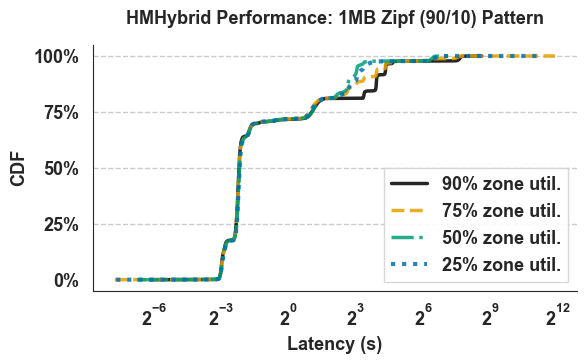

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a more compact figure with reduced whitespace
fig_width_pt = 241.02039 * 1.75
inches_per_pt = 1.0/72.27               # Convert pt to inches
golden_mean = (math.sqrt(5)-1.0)/2.0         # Aesthetic ratio
fig_width = fig_width_pt*inches_per_pt  # width in inches
fig_height =fig_width*golden_mean       # height in inches
fig_size = [fig_width,fig_height]
plt.figure(figsize=fig_size)

# Set up clean styling
sns.set_theme()
sns.set_style("white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

# Colorblind-friendly palette (Paul Tol's vibrant palette)
colors = {
    '90%': '#000000',  # Orange
    '75%': '#E69F00',  # Blue  
    '50%': '#009E73',  # Light blue
    '25%': '#0072B2',  # Teal
    'extra': '#D55E00'  # Red - perfect for adding another series
}

# Performance optimizations
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.1

# 90% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
plt.plot(data_sorted, cdf, linestyle='-', 
         label="90% zone util.", color=colors['90%'], 
         linewidth=2.5, alpha=0.85)

# 75% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/75Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
plt.plot(data_sorted, cdf, linestyle='--', 
         label="75% zone util.", color=colors['75%'], 
         linewidth=2.5, alpha=0.85)

# 50% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/50Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
plt.plot(data_sorted, cdf, linestyle='-.', 
         label="50% zone util.", color=colors['50%'], 
         linewidth=2.5, alpha=0.85)

# 25% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/25Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
plt.plot(data_sorted, cdf, linestyle=':', 
         label="25% zone util.", color=colors['25%'], 
         linewidth=3.0, alpha=0.85)

# Set log scale for x-axis
plt.xscale('log', base=2)

# Clean styling - no grid
plt.grid(False)

# Add percentile reference lines
percentiles = [0.25, 0.5, 0.75, 1]  # 25th, 50th, 75th, 90th, 95th, 99th percentiles
for p in percentiles:
    plt.axhline(y=p, color='gray', linestyle='--', alpha=0.4, linewidth=1, zorder=0)

# Set ticks and labels with better spacing - include key percentiles
ytick_positions = [0, 0.25, 0.5, 0.75, 1]
ytick_labels = ['0%', '25%', '50%', '75%', '100%']
plt.yticks(ytick_positions, ytick_labels, fontsize=13, fontweight='semibold')
plt.xticks(fontsize=13, fontweight='semibold')

# Labels and title with improved typography
plt.xlabel('Latency (s)', fontsize=13, fontweight='semibold')
plt.ylabel('CDF', fontsize=13, fontweight='semibold')
plt.title('HMHybrid Performance: 1MB Zipf (90/10) Pattern', 
          fontsize=13, fontweight='semibold', pad=15)

# Improved legend
plt.legend(prop={'size':13, 'weight':'semibold'},  frameon=True, fancybox=False, 
           shadow=False, framealpha=0.9, edgecolor='lightgray',
           loc='lower right')

# Reduce whitespace around the plot
plt.tight_layout(pad=0.5)

# Remove top and right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Uncomment to save with high quality
# plt.savefig("figs/1M_DMHybrid_CDF_ZoneUtilization_improved.png", 
#             bbox_inches='tight', dpi=300, facecolor='white')
# Uncomment to save with high quality
plt.savefig("/Users/Puneet89/Documents/smr_paper/figures/HM-Hybrid/1MB/1M_HMHybrid_CDF_9010Zipf_AllZoneUtilizations.pdf", 
             bbox_inches='tight', dpi=600, facecolor='white')
plt.show()